In [43]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [44]:
!pip install hdbscan

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import folium
from folium.plugins import HeatMap
import hdbscan

In [46]:
path = "/content/gdrive/MyDrive/machine_learning/pertemuan11"

In [47]:
df = pd.read_csv(path + '/praktikum_mandiri/data/katalog_gempa.csv')
df

,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92882,2023/01/26,02:25:09.288,3.24,127.18,10,4.0,Talaud Islands - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
92883,2023/01/26,02:15:03.893,2.70,127.10,10,3.9,Northern Molucca Sea,NaN,NaN,NaN,NaN,NaN,NaN
92884,2023/01/26,01:57:08.885,-7.83,121.07,10,3.8,Flores Sea,NaN,NaN,NaN,NaN,NaN,NaN
92885,2023/01/26,01:46:21.009,3.00,127.16,10,4.1,Northern Molucca Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
df = df.drop(['ot','strike1', 'dip1', 'rake1', 'strike2', 'dip2', 'rake2'], axis=1)

In [49]:
df['tgl'] = pd.to_datetime(df['tgl'])

In [50]:
df.isnull().sum()

,0
tgl,0
lat,0
lon,0
depth,0
mag,0
remark,0


In [51]:
df

,tgl,lat,lon,depth,mag,remark
0,2008-11-01,-9.18,119.06,10,4.9,Sumba Region - Indonesia
1,2008-11-01,-6.55,129.64,10,4.6,Banda Sea
2,2008-11-01,-7.01,106.63,121,3.7,Java - Indonesia
3,2008-11-01,-3.30,127.85,10,3.2,Seram - Indonesia
4,2008-11-01,-6.41,129.54,70,4.3,Banda Sea
...,...,...,...,...,...,...
92882,2023-01-26,3.24,127.18,10,4.0,Talaud Islands - Indonesia
92883,2023-01-26,2.70,127.10,10,3.9,Northern Molucca Sea
92884,2023-01-26,-7.83,121.07,10,3.8,Flores Sea
92885,2023-01-26,3.00,127.16,10,4.1,Northern Molucca Sea


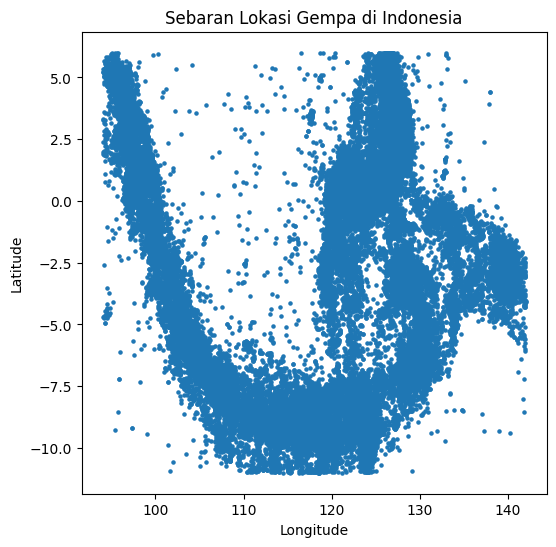

In [52]:
# ===========================================
# 4️⃣ EXPLORATORY DATA ANALYSIS (EDA)
# ===========================================

# Scatter plot persebaran gempa
plt.figure(figsize=(6,6))
plt.scatter(df['lon'], df['lat'], s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sebaran Lokasi Gempa di Indonesia")
plt.show()


In [53]:
from sklearn.preprocessing import StandardScaler

# ===========================================
# 5️⃣ NORMALISASI DATA
# ===========================================

# Select only numerical columns for scaling
df_numerical = df[['lat', 'lon', 'depth', 'mag']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numerical)

data_scaled[:5]

array([[-1.3262929 , -0.00920386, -0.50819522,  1.56732953],
       [-0.72232838,  0.96742863, -0.50819522,  1.20763358],
       [-0.82796476, -1.15660857,  0.93785807,  0.12854573],
       [ 0.0240156 ,  0.80219496, -0.50819522, -0.47094752],
       [-0.69017818,  0.9581977 ,  0.27345521,  0.84793763]])

In [54]:
# ===========================================
# 6️⃣ HDBSCAN CLUSTERING
# ===========================================
clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
labels = clusterer.fit_predict(data_scaled)

df['cluster'] = labels
df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,tgl,lat,lon,depth,mag,remark,cluster
0,2008-11-01,-9.18,119.06,10,4.9,Sumba Region - Indonesia,-1
1,2008-11-01,-6.55,129.64,10,4.6,Banda Sea,-1
2,2008-11-01,-7.01,106.63,121,3.7,Java - Indonesia,-1
3,2008-11-01,-3.30,127.85,10,3.2,Seram - Indonesia,29
4,2008-11-01,-6.41,129.54,70,4.3,Banda Sea,-1


In [55]:
# Jumlah cluster dan noise (-1)
print(df['cluster'].value_counts())

cluster
-1     63456
 13     3914
 36     3025
 6      2343
 11     1910
       ...  
 97       55
 52       52
 90       51
 53       51
 40       50
Name: count, Length: 108, dtype: int64


In [56]:
total_gempa = df.shape[0]
jumlah_gempa_per_hari = df.groupby(df['tgl'].dt.date).size()

rata_rata_gempa_per_hari = jumlah_gempa_per_hari.mean()

print('Total jumlah gempa:', total_gempa)
print('Rata-rata jumlah gempa per hari:', rata_rata_gempa_per_hari)

Total jumlah gempa: 92887
Rata-rata jumlah gempa per hari: 21.053263825929285


In [57]:
# Mencari nilai min dan max dari 'mag'
min_mag = df['mag'].min()
max_mag = df['mag'].max()
print ('magnitudo terkecil:', min_mag)
print ('magnitudo terbesar:', max_mag)

# Keterangan gempa berdasarkan magnitudo
bins = [float('-inf'), 3.0, 4.0, float('inf')]  # Defining bin edges
labels = ['Kecil', 'Sedang', 'Kuat']  # Labels for the groups
df['keterangan'] = pd.cut(df['mag'], bins=bins, labels=labels, right=False)  # Group by mag
print(df[['tgl', 'mag', 'keterangan']])

magnitudo terkecil: 1.0
magnitudo terbesar: 7.9
             tgl  mag keterangan
0     2008-11-01  4.9       Kuat
1     2008-11-01  4.6       Kuat
2     2008-11-01  3.7     Sedang
3     2008-11-01  3.2     Sedang
4     2008-11-01  4.3       Kuat
...          ...  ...        ...
92882 2023-01-26  4.0       Kuat
92883 2023-01-26  3.9     Sedang
92884 2023-01-26  3.8     Sedang
92885 2023-01-26  4.1       Kuat
92886 2023-01-26  2.4      Kecil

[92887 rows x 3 columns]


/tmp/ipython-input-1779060292.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keterangan_counts.index, y=keterangan_counts.values, palette="viridis")


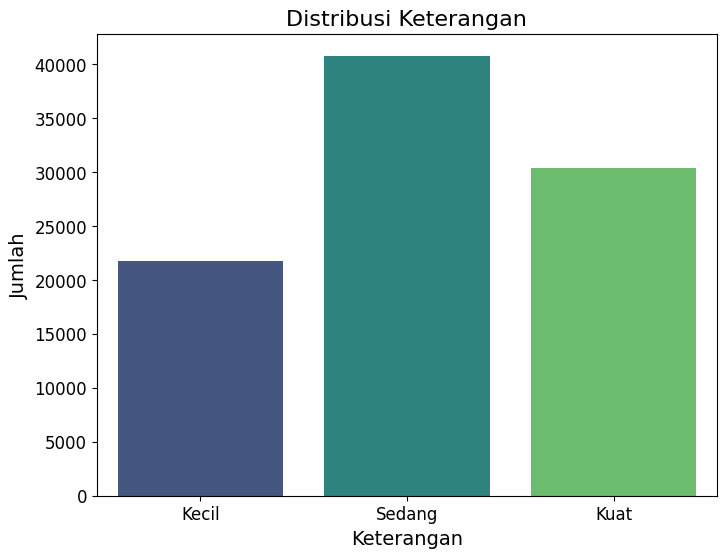

In [58]:
# Hitung jumlah data di setiap kategori
keterangan_counts = df['keterangan'].value_counts()

# Buat plot bar menggunakan Matplotlib
plt.figure(figsize=(8, 6))
sns.barplot(x=keterangan_counts.index, y=keterangan_counts.values, palette="viridis")
plt.title('Distribusi Keterangan', fontsize=16)
plt.xlabel('Keterangan', fontsize=14)
plt.ylabel('Jumlah', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [59]:
# ===========================================
# 7️⃣ SILHOUETTE SCORE (Hanya untuk data bukan noise)
# ===========================================
valid = df[df.cluster != -1]

if len(valid['cluster'].unique()) > 1:
    score = silhouette_score(valid[['lat','lon','depth','mag']], valid['cluster'])
    print("Silhouette Score:", score)
else:
    print("Silhouette score tidak bisa dihitung (cluster hanya 1 atau noise terlalu banyak)")


Silhouette Score: 0.06435883168865836


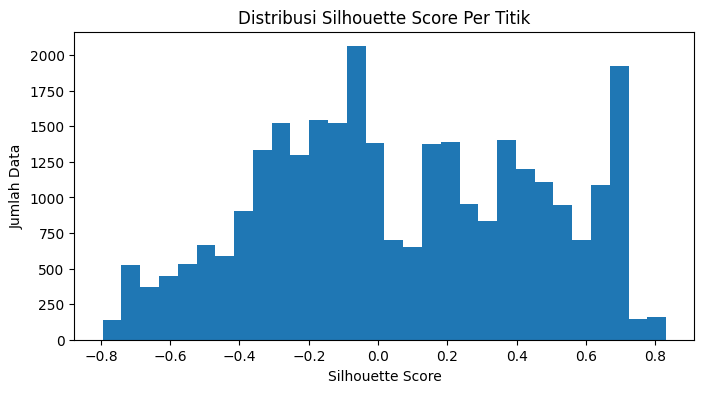

In [60]:
sample_scores = silhouette_samples(valid[['lat','lon','depth','mag']], valid['cluster'])

plt.figure(figsize=(8,4))
plt.hist(sample_scores, bins=30)
plt.title("Distribusi Silhouette Score Per Titik")
plt.xlabel("Silhouette Score")
plt.ylabel("Jumlah Data")
plt.show()


In [61]:
# ===========================================
# 8️⃣ VISUALISASI CLUSTERING DI PETA (Folium)
# ===========================================

# Buat peta pusat Indonesia
m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=5)

# Warna random untuk tiap cluster
colors = {}
for c in df['cluster'].unique():
    if c == -1:
        colors[c] = "gray"
    else:
        colors[c] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# Tambahkan titik cluster ke peta
for _, row in df.sample(3000).iterrows():  # sample biar peta tidak berat
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color=colors[row['cluster']],
        fill=True
    ).add_to(m)

m

In [62]:
# ===========================================
# 9️⃣ HEATMAP PADA PETA
# ===========================================
m2 = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=5)

heat_data = df[['lat','lon']].values.tolist()
HeatMap(heat_data, radius=8).add_to(m2)

m2